Step 1/20 | Acc: 0.3287
Step 2/20 | Acc: 0.5896
Step 3/20 | Acc: 0.7749
Step 4/20 | Acc: 0.8502
Step 5/20 | Acc: 0.9062
Step 6/20 | Acc: 0.9317
Step 7/20 | Acc: 0.9426
Step 8/20 | Acc: 0.9478
Step 9/20 | Acc: 0.9495
Step 10/20 | Acc: 0.9501
Step 11/20 | Acc: 0.9513
Step 12/20 | Acc: 0.9519
Step 13/20 | Acc: 0.9527
Step 14/20 | Acc: 0.9531
Step 15/20 | Acc: 0.9533
Step 16/20 | Acc: 0.9544
Step 17/20 | Acc: 0.9545
Step 18/20 | Acc: 0.9551
Step 19/20 | Acc: 0.9570
Step 20/20 | Acc: 0.9677
Mean acquisition accuracy: 0.886115


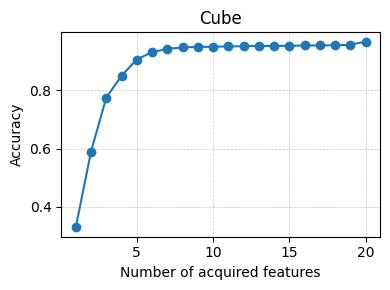

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/cube/X_train_cdf.pt").float()
y_train = torch.load(f"../data/cube/y_train.pt").long()

X_val   = torch.load(f"../data/cube/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/cube/y_val.pt").long()

X_test = torch.load(f"../data/cube/X_test_cdf.pt").float()
y_test = torch.load(f"../data/cube/y_test.pt").long()

num_features = 20
num_classes = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 8   # per-feature latent dim
enc_hidden_dim = 16   # JointEncoder 내부 attention token dim
dec_hidden_dim = 64 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 4 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_cube.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=15.0,
    gamma=0.0
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("Accuracy")
ax.set_title("Cube")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

Step 1/15 | Acc: 0.8815
Step 2/15 | Acc: 0.8815
Step 3/15 | Acc: 0.8815
Step 4/15 | Acc: 0.8826
Step 5/15 | Acc: 0.8828
Step 6/15 | Acc: 0.8835
Step 7/15 | Acc: 0.8839
Step 8/15 | Acc: 0.8859
Step 9/15 | Acc: 0.8877
Step 10/15 | Acc: 0.8905
Step 11/15 | Acc: 0.8919
Step 12/15 | Acc: 0.8950
Step 13/15 | Acc: 0.8950
Step 14/15 | Acc: 0.8976
Step 15/15 | Acc: 0.8996
Mean acquisition accuracy: 0.8880141530296329


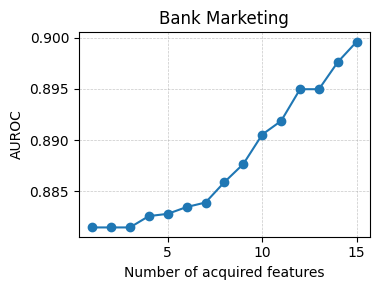

In [75]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/bank_marketing/X_train_cdf.pt").float()
y_train = torch.load(f"../data/bank_marketing/y_train.pt").long()

X_val   = torch.load(f"../data/bank_marketing/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/bank_marketing/y_val.pt").long()

X_test = torch.load(f"../data/bank_marketing/X_test_cdf.pt").float()
y_test = torch.load(f"../data/bank_marketing/y_test.pt").long()

num_features = 15
num_classes = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 8   # per-feature latent dim
enc_hidden_dim = 16   # JointEncoder 내부 attention token dim
dec_hidden_dim = 64 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 4 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_bank_marketing.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.7
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("AUROC")
ax.set_title("Bank Marketing")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

Step 1/8 | Acc: 0.4327
Step 2/8 | Acc: 0.5465
Step 3/8 | Acc: 0.6211
Step 4/8 | Acc: 0.6623
Step 5/8 | Acc: 0.6827
Step 6/8 | Acc: 0.6977
Step 7/8 | Acc: 0.7049
Step 8/8 | Acc: 0.7263
Mean acquisition accuracy: 0.634265988372093


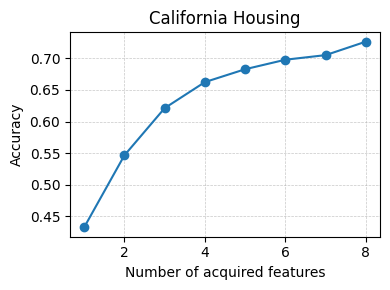

In [73]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/california_housing/X_train_cdf.pt").float()
y_train = torch.load(f"../data/california_housing/y_train.pt").long()

X_val   = torch.load(f"../data/california_housing/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/california_housing/y_val.pt").long()

X_test = torch.load(f"../data/california_housing/X_test_cdf.pt").float()
y_test = torch.load(f"../data/california_housing/y_test.pt").long()

num_features = 8
num_classes = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 16   # per-feature latent dim
enc_hidden_dim = 64   # JointEncoder 내부 attention token dim
dec_hidden_dim = 256  # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 8 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_california_housing.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.6
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("Accuracy")
ax.set_title("California Housing")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

Step 1/20 | Acc: 0.7665
Step 2/20 | Acc: 0.8114
Step 3/20 | Acc: 0.8387
Step 4/20 | Acc: 0.8555
Step 5/20 | Acc: 0.8686
Step 6/20 | Acc: 0.8753
Step 7/20 | Acc: 0.8829
Step 8/20 | Acc: 0.8888
Step 9/20 | Acc: 0.8952
Step 10/20 | Acc: 0.8983
Step 11/20 | Acc: 0.9019
Step 12/20 | Acc: 0.9048
Step 13/20 | Acc: 0.9077
Step 14/20 | Acc: 0.9099
Step 15/20 | Acc: 0.9137
Step 16/20 | Acc: 0.9169
Step 17/20 | Acc: 0.9165
Step 18/20 | Acc: 0.9180
Step 19/20 | Acc: 0.9203
Step 20/20 | Acc: 0.9210
Mean acquisition accuracy: 0.885595


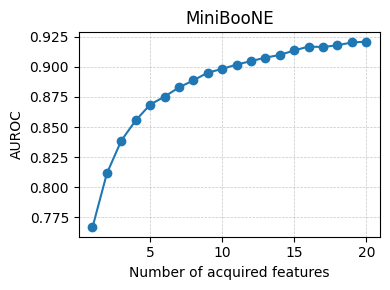

In [78]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/miniboone/X_train_cdf.pt").float()
y_train = torch.load(f"../data/miniboone/y_train.pt").long()

X_val   = torch.load(f"../data/miniboone/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/miniboone/y_val.pt").long()

X_test = torch.load(f"../data/miniboone/X_test_cdf.pt").float()
y_test = torch.load(f"../data/miniboone/y_test.pt").long()

num_features = 20
num_classes = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 64   # per-feature latent dim
enc_hidden_dim = 8   # JointEncoder 내부 attention token dim
dec_hidden_dim = 256 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 8 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_miniboone.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.0
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("AUROC")
ax.set_title("MiniBooNE")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

Step 1/20 | Acc: 0.1846
Step 2/20 | Acc: 0.2703
Step 3/20 | Acc: 0.3474
Step 4/20 | Acc: 0.4217
Step 5/20 | Acc: 0.4954
Step 6/20 | Acc: 0.5476
Step 7/20 | Acc: 0.6019
Step 8/20 | Acc: 0.6495
Step 9/20 | Acc: 0.6943
Step 10/20 | Acc: 0.7240
Step 11/20 | Acc: 0.7558
Step 12/20 | Acc: 0.7860
Step 13/20 | Acc: 0.8090
Step 14/20 | Acc: 0.8267
Step 15/20 | Acc: 0.8429
Step 16/20 | Acc: 0.8566
Step 17/20 | Acc: 0.8681
Step 18/20 | Acc: 0.8815
Step 19/20 | Acc: 0.8923
Step 20/20 | Acc: 0.9007
Mean acquisition accuracy: 0.6678150000000002


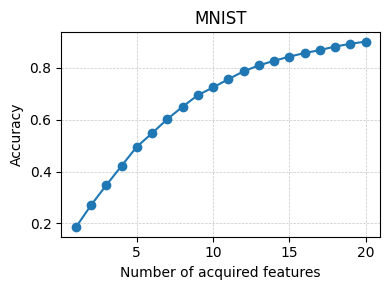

In [105]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/mnist/X_train_cdf.pt").float()
y_train = torch.load(f"../data/mnist/y_train.pt").long()

X_val   = torch.load(f"../data/mnist/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/mnist/y_val.pt").long()

X_test = torch.load(f"../data/mnist/X_test_cdf.pt").float()
y_test = torch.load(f"../data/mnist/y_test.pt").long()

num_features = 20
num_classes = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 16   # per-feature latent dim
enc_hidden_dim = 32   # JointEncoder 내부 attention token dim
dec_hidden_dim = 256 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 8 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_mnist.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.6
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("Accuracy")
ax.set_title("MNIST")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

Step 1/20 | Acc: 0.2153
Step 2/20 | Acc: 0.3369
Step 3/20 | Acc: 0.4535
Step 4/20 | Acc: 0.5304
Step 5/20 | Acc: 0.5859
Step 6/20 | Acc: 0.6284
Step 7/20 | Acc: 0.6609
Step 8/20 | Acc: 0.6909
Step 9/20 | Acc: 0.7107
Step 10/20 | Acc: 0.7309
Step 11/20 | Acc: 0.7439
Step 12/20 | Acc: 0.7528
Step 13/20 | Acc: 0.7604
Step 14/20 | Acc: 0.7662
Step 15/20 | Acc: 0.7727
Step 16/20 | Acc: 0.7753
Step 17/20 | Acc: 0.7868
Step 18/20 | Acc: 0.7902
Step 19/20 | Acc: 0.7930
Step 20/20 | Acc: 0.7984
Mean acquisition accuracy: 0.664175


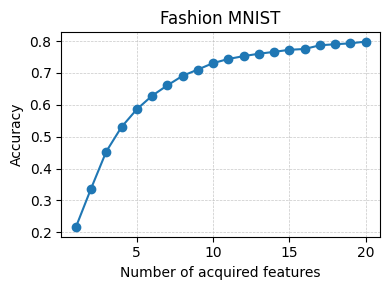

In [104]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/fashion_mnist/X_train_cdf.pt").float()
y_train = torch.load(f"../data/fashion_mnist/y_train.pt").long()

X_val   = torch.load(f"../data/fashion_mnist/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/fashion_mnist/y_val.pt").long()

X_test = torch.load(f"../data/fashion_mnist/X_test_cdf.pt").float()
y_test = torch.load(f"../data/fashion_mnist/y_test.pt").long()

num_features = 20
num_classes = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 16   # per-feature latent dim
enc_hidden_dim = 32   # JointEncoder 내부 attention token dim
dec_hidden_dim = 256 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 8 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_fashion_mnist.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.1
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("Accuracy")
ax.set_title("Fashion MNIST")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

Step 1/12 | Acc: 0.4293
Step 2/12 | Acc: 0.5602
Step 3/12 | Acc: 0.6126
Step 4/12 | Acc: 0.6126
Step 5/12 | Acc: 0.6073
Step 6/12 | Acc: 0.6283
Step 7/12 | Acc: 0.6492
Step 8/12 | Acc: 0.6649
Step 9/12 | Acc: 0.6649
Step 10/12 | Acc: 0.6911
Step 11/12 | Acc: 0.6911
Step 12/12 | Acc: 0.6859
Mean acquisition accuracy: 0.6247818499127399


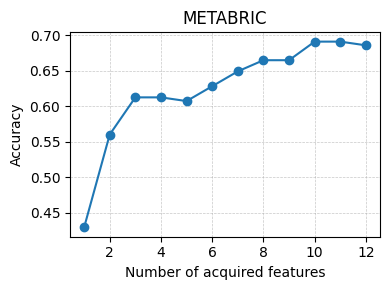

In [121]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from train_utils import (
    run_feature_acquisition
)

from joint_model import (
    StudentModel,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # blackwell

X_train = torch.load(f"../data/metabric/X_train_cdf.pt").float()
y_train = torch.load(f"../data/metabric/y_train.pt").long()

X_val   = torch.load(f"../data/metabric/X_val_cdf.pt").float()
y_val   = torch.load(f"../data/metabric/y_val.pt").long()

X_test = torch.load(f"../data/metabric/X_test_cdf.pt").float()
y_test = torch.load(f"../data/metabric/y_test.pt").long()

num_features = 12
num_classes = 6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256

train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

z_dim          = 2   # per-feature latent dim
enc_hidden_dim = 16   # JointEncoder 내부 attention token dim
dec_hidden_dim = 256 # predictor MLP hidden dim
dec_num_hidden = 2    # predictor MLP hidden layer 개수
num_heads      = 8 # attention head의 개수

student = StudentModel(
    num_features=num_features,
    z_dim=z_dim,
    enc_hidden_dim=enc_hidden_dim,
    num_heads=num_heads,
    dec_hidden_dim=dec_hidden_dim,
    dec_num_hidden=dec_num_hidden,
    out_dim=num_classes,
).to(device)

ckpt = torch.load("../checkpoints/student_metabric.pt", map_location=device)
student.load_state_dict(ckpt) 

student.eval()
result = []

accs = run_feature_acquisition(
    predictor=student,
    X_test=X_test,
    y_test=y_test,
    alpha=1.0,
    gamma=0.0
)

result.append(accs)

mean_acc = np.mean(accs)
print("Mean acquisition accuracy:", mean_acc)

accs = np.array(accs)  # (K,) 라고 가정
K = np.arange(1, len(accs) + 1)  # K = 1,2,...,num_features

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(K, accs, marker='o')  # 기본 색/스타일 사용
ax.set_xlabel("Number of acquired features")
ax.set_ylabel("Accuracy")
ax.set_title("METABRIC")  # 캡션 제목

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()